# Generic tracker simulator

## 1.- Goals of this notebook

* To understand basic concepts about tracker software.
* Visualize tracks in a synthetic tracker.
* Generate a small dataset of events with a synthetic tracker.

Please download the libraries in order to start.

In [ ]:
!rm -rf InstrumentationSchool/
!git clone https://github.com/parbol/InstrumentationSchool.git
import sys
sys.path.append('/content/InstrumentationSchool')

Cloning into 'InstrumentationSchool'...
remote: Enumerating objects: 593, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 593 (delta 53), reused 114 (delta 36), pack-reused 445 (from 1)
Receiving objects: 100% (593/593), 308.64 KiB | 5.61 MiB/s, done.
Resolving deltas: 100% (250/250), done.


## 2.- The Generic Tracker module

This module implements a configurable tracker and most of the software functionallities associated to it. The code is formed by several packages:

| Package    | Function |
| -------- | ------- |
| Geometry  | Implements all the geometrical objects involved in the construction of the tracker.    |
| Generation | Modules related to generated Particles     |
| Navigation | Modules related to the navitation of the particles through the layers |
| Tools | Mostly mathematical tools used by others |
| Propagation | Modules with elements needed to propagate particles through the tracker |




## 3.- Importing libraries

This module uses the following libraries:

In [ ]:
from GenericTrackerSimulator.src.Geometry.FullTracker import FullTracker
from GenericTrackerSimulator.src.Geometry.Tracker import Tracker
from GenericTrackerSimulator.src.Geometry.BarrelLayer import BarrelLayer
from GenericTrackerSimulator.src.Geometry.EndcapDisk import EndcapDisk
from GenericTrackerSimulator.src.Geometry.GeometryBuilder import GeometryBuilder
from GenericTrackerSimulator.src.Geometry.GeometryTools import GeometryTools
from GenericTrackerSimulator.src.Generation.genParticle import genParticle

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import logging
import sys

## 4.- Running your first tracker

In the next block you will create your first tracker. This tracker is hardcoded in the GeometryBuilder module. You have to take into account that the basic geometric layout uses the following concepts:

* **BarrelLayer**: A layer in the barrel that contains trays around the interaction point.
* **EndcapDisk**: A disk in the endcap containing trays.
* **Tray**: It is a rectangular plane that holds modules.
* **Module**: It is a rectangular plane that acts as the sensing part of the tracker.

In [ ]:
gBuilder = GeometryBuilder()
#If we want to generate a geometry from Geometry Builder
gBuilder.build()
gTools = GeometryTools(gBuilder.ftr)

## 5.- Draw the tracker and play with the parameters

In this block you will be able to visualize the tracker. Play with the parameters in GeometryBuilder to build different trackers and visualize them. In particular try plotting also the endcaps, reducing the number of layers in the barrel, reducing the number of trays, and playing with the number of modules.

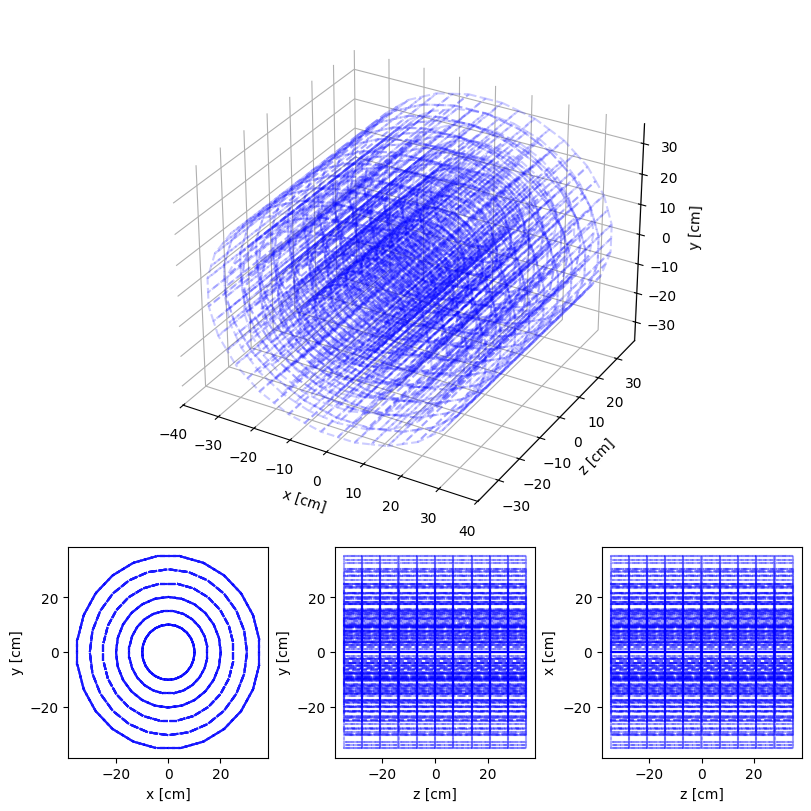

In [ ]:
#Plotting scheme
fig = plt.figure(figsize = (8, 8), layout="constrained")
gs0 = fig.add_gridspec(2, 1, height_ratios=[2,1])
ax1 = fig.add_subplot(gs0[0], projection = '3d')
gs1 = gs0[1].subgridspec(1,3)
ax2 = fig.add_subplot(gs1[0])
ax3 = fig.add_subplot(gs1[1])
ax4 = fig.add_subplot(gs1[2])
ax1.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.set_xlabel('x [cm]')
ax1.set_ylabel('z [cm]')
ax1.set_zlabel('y [cm]')
ax2.set_xlabel('x [cm]')
ax2.set_ylabel('y [cm]')
ax3.set_xlabel('z [cm]')
ax3.set_ylabel('y [cm]')
ax4.set_xlabel('z [cm]')
ax4.set_ylabel('x [cm]')

gBuilder.ftr.drawBarrel(ax1, ax2, ax3, ax4, t='b--')



## 6.- A few questions before you continue

Q. What is the purpose of the navigation sub package?

A.

Q. How is the propagation working?

A.

Q. What do we understand by a genParticle?

A.

Q. Can you explain what are the arguments needed by genParticle?

A.

## 7.- Load a predefined tracker from a json file

Just use the tracker that I prepared for you.

In [ ]:
##### Getting the data
import urllib.request

urllib.request.urlretrieve('https://nextcloud.ifca.es/index.php/s/Ad4Aa4SqiexBQjz/download', 'tracker.json')
print("Data downloaded successfully")

newGBuilder = GeometryBuilder()
newGTools = GeometryTools(newGBuilder.ftr)
newGTools.importGeometry('tracker.json')

#Building the navigator links
newGBuilder.ftr.setNavigator()


Data downloaded successfully


## 8.- Run some particles on your new tracker

Now you are asked to produce a bunch of particles. This task is computationally intense so do not use more than 20 particles.

Fill the information in the proposed dictionary. Take the following statistical distributions:

* x, y, z and t will be just 0
* phi -> uniform distribution from 0 to 2pi
* eta -> uniform distribution from -0.5 to 0.5
* pt -> uniform distribution from 0.5 to 10.0
* mass -> fixed to the mass of the pion (0.1395 GeV)
* charge -> random bewteen -1 and 1
* id -> fixed to the pion (121)

Processing particle number: 0
Processing particle number: 1
Processing particle number: 2
Processing particle number: 3
Processing particle number: 4


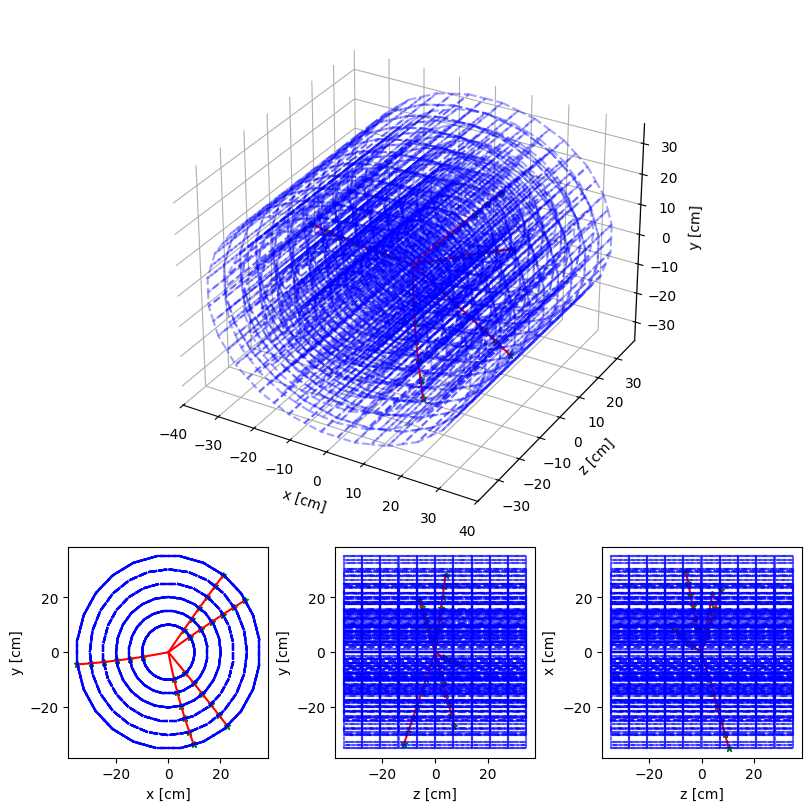

In [ ]:
#Plotting scheme
fig = plt.figure(figsize = (8, 8), layout="constrained")
gs0 = fig.add_gridspec(2, 1, height_ratios=[2,1])
ax1 = fig.add_subplot(gs0[0], projection = '3d')
gs1 = gs0[1].subgridspec(1,3)
ax2 = fig.add_subplot(gs1[0])
ax3 = fig.add_subplot(gs1[1])
ax4 = fig.add_subplot(gs1[2])
ax1.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax1.set_xlabel('x [cm]')
ax1.set_ylabel('z [cm]')
ax1.set_zlabel('y [cm]')
ax2.set_xlabel('x [cm]')
ax2.set_ylabel('y [cm]')
ax3.set_xlabel('z [cm]')
ax3.set_ylabel('y [cm]')
ax4.set_xlabel('z [cm]')
ax4.set_ylabel('x [cm]')

nParticles = 5
counterNodes = 0
counter = 0
nLayers = 6

particle = dict()
particle['particle'] = []
particle['x'] = []
particle['y'] = []
particle['z'] = []
particle['layer'] = []
particle['pt'] = []
particle['charge'] = []
particle['label'] = []

newGBuilder.ftr.drawBarrel(ax1, ax2, ax3, ax4, t='b--')

while counter < nParticles:
  print(f'Processing particle number: {counter}')
  x = y = z = t = 0
  phi = np.random.uniform(0.0, 2.0*np.pi)
  eta = np.random.uniform(-0.5, 0.5)
  pt = np.random.uniform(0.5, 10.0)
  mass = 0.1395
  charge = np.sign(np.random.uniform(-1.0, 1.0))
  id = 121
  p = genParticle(x = x, y = y, z = z, t = t, phi = phi, eta = eta, pt = pt, mass = mass, q=charge, id = id)
  p.print()
  newGBuilder.ftr.propagateParticle(p)

  if len(p.intersections) != nLayers:
    continue

  for i, tks in enumerate(p.intersections):
    mod = p.intersections[i][0]
    tks = p.intersections[i][1]
    particle['particle'].append(counter)
    particle['x'].append(tks.x)
    particle['y'].append(tks.y)
    particle['z'].append(tks.z)
    particle['layer'].append(mod.barrelIndex)
    particle['pt'].append(tks.pt)
    particle['charge'].append(tks.q)
    particle['label'].append(counterNodes)
    counterNodes = counterNodes + 1


  p.drawIntersections(ax1, ax2, ax3, ax4, t='g*')
  p.draw(newGBuilder.ftr.propagator.B, ax1, ax2, ax3, ax4, fmt='r')
  counter = counter + 1
df = pd.DataFrame(particle)
df.to_parquet('particleTracking.parquet')
